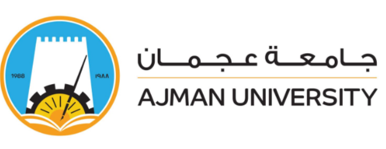

College: Engineering and Information Technology

Department: Information Technology

Academic semester: Fall 2025- 2026

Busi. Intell. & Data Warehousing course Project



```
Ecommerce Order & Supply Chain
```


**Prepared by:**

Aya Alnajjar – 202210912

Sabrin Ibrahim – 202111554

Salma Roshdy – 202211182

Lujin tamer– 202110294




**Supervised by:**

> Dr. Ghazi AlNaymat


Dataset used:

https://www.kaggle.com/datasets/bytadit/ecommerce-order-dataset

# Dataset Overview

...

- The dataset is an anonymized e-commerce transactions log containing real purchases over multiple months.
- It consists of 5 interconnected files: Orders, Order Items, Customers, Payments, and Products — linked by keys like order_id, product_id, and customer_id.
- The data captures the purchase journey from order placement to delivery and includes pricing, shipping, and customer location details — making it
ideal for end-to-end sales analysis and behavioral insights.
- The entries span across 2016–2018, but early 2016 data is mostly synthetic/test-like and was excluded in the cleaning stage going ahead.
- The raw data had inconsistencies, outliers, and relational issues which are pointed out in the notebook, and were addressed during Data Cleaning process to ensure accurate exploratory analysis and insight generation.

# Importing Libraries

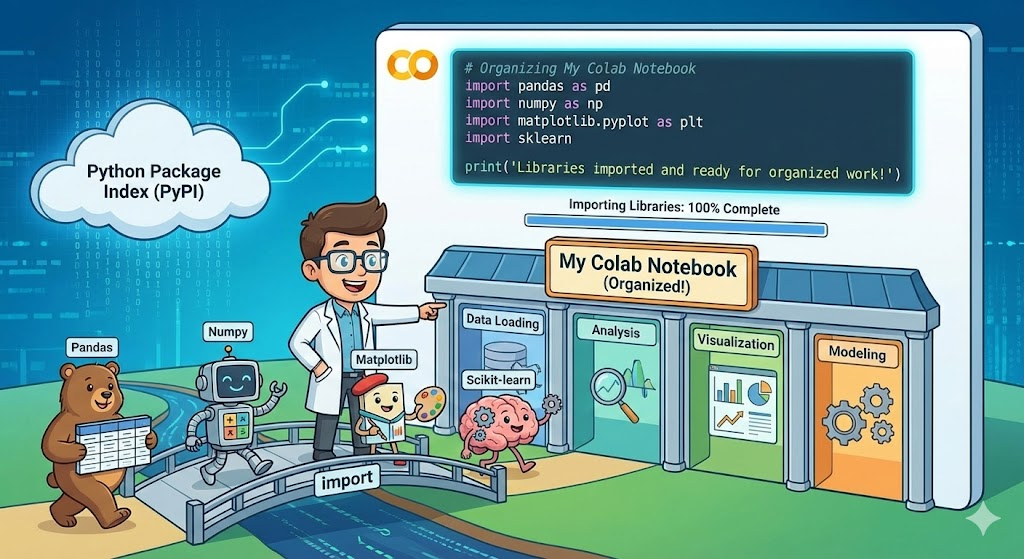

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
import os
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print(" Libraries imported successfully!")

 Libraries imported successfully!


# Data Loading (Mount Drive) & Overview

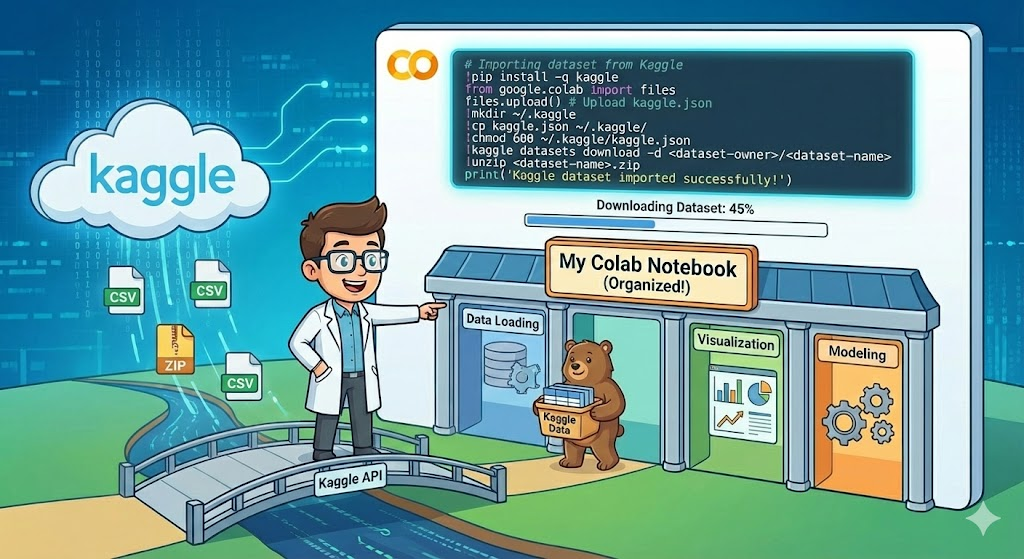

In [ ]:
# Mount Google Drive.
from google.colab import drive
drive.mount('/content/drive')
base_path = "/content/drive/MyDrive/BI project"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Define train and test paths
train_path = os.path.join(base_path, "train")
test_path  = os.path.join(base_path, "test")

# Load training CSV files
train_orders      = pd.read_csv(os.path.join(train_path, "df_Orders.csv"))
train_orderitems  = pd.read_csv(os.path.join(train_path, "df_OrderItems.csv"))
train_customers   = pd.read_csv(os.path.join(train_path, "df_Customers.csv"))
train_payments    = pd.read_csv(os.path.join(train_path, "df_Payments.csv"))
train_products    = pd.read_csv(os.path.join(train_path, "df_Products.csv"))

# Load testing CSV files
test_orders      = pd.read_csv(os.path.join(test_path, "df_Orders.csv"))
test_orderitems  = pd.read_csv(os.path.join(test_path, "df_OrderItems.csv"))
test_customers   = pd.read_csv(os.path.join(test_path, "df_Customers.csv"))
test_payments    = pd.read_csv(os.path.join(test_path, "df_Payments.csv"))
test_products    = pd.read_csv(os.path.join(test_path, "df_Products.csv"))

print("Data loaded successfully!")

Data loaded successfully!


In [ ]:
test_orders

,order_id,customer_id,order_purchase_timestamp,order_approved_at
0,u6rPMRAYIGig,I74lXDOfoqsp,2017-11-18 12:29:57,2017-11-18 12:46:08
1,ohY8f4FEbX19,47TuLHF2s7X5,2018-06-02 17:13:12,2018-06-02 20:12:23
2,I28liQek73i2,dQ0dqI8Qwlj8,2018-01-08 11:01:30,2018-01-09 07:24:03
3,bBG1T89mlY8W,iQCmWhNkIczb,2017-03-10 10:24:46,2017-03-10 10:24:46
4,CYxJJSQS8Lbo,Dp2g6JH8tO5Z,2017-12-02 10:04:07,2017-12-05 04:13:30
...,...,...,...,...
38274,QKBW3XKevmfn,Dw3aCTFf4Q4G,2018-08-24 11:54:56,2018-08-24 12:05:22
38275,Tjiw9bj8HtLr,JmHJqJvpVcJs,2017-03-25 20:39:11,2017-03-25 20:50:17
38276,mCPofb7A1aTq,ro5DikwWCC3j,2018-08-16 13:39:30,2018-08-17 03:31:06
38277,scVuqN10zbgb,R25nE2rl77AU,2018-06-27 13:17:05,2018-06-28 08:50:58


### TRAINING DATA

In [ ]:
print("DATA SHAPE & STRUCTURE")


datasets = {
    "Orders": train_orders,
    "Order Items": train_orderitems,
    "Customers": train_customers,
    "Payments": train_payments,
    "Products": train_products
}


for name, df in datasets.items():
    print(f"\n{name}")
    print("-" * 80)
    print(f"Rows      : {df.shape[0]:,}")
    print(f"Columns   : {df.shape[1]}")
    print(f"Memory    : {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

print()
print("All training datasets loaded and summarized successfully!")


DATA SHAPE & STRUCTURE

Orders
--------------------------------------------------------------------------------
Rows      : 89,316
Columns   : 7
Memory    : 37.67 MB

Order Items
--------------------------------------------------------------------------------
Rows      : 89,316
Columns   : 5
Memory    : 16.95 MB

Customers
--------------------------------------------------------------------------------
Rows      : 89,316
Columns   : 4
Memory    : 15.27 MB

Payments
--------------------------------------------------------------------------------
Rows      : 89,316
Columns   : 5
Memory    : 12.25 MB

Products
--------------------------------------------------------------------------------
Rows      : 89,316
Columns   : 6
Memory    : 12.63 MB

All training datasets loaded and summarized successfully!


The output confirms that all datasets (Orders, Order Items, Customers, Payments, and Products) were successfully loaded.

Each section shows the number of rows, columns, and memory usage, giving a quick overview of the dataset sizes.
All five tables have 89,316 rows, indicating they are likely related through a common key (e.g., order ID).

In [ ]:
train_customers.columns

Index(['customer_id', 'customer_zip_code_prefix', 'customer_city',
       'customer_state'],
      dtype='object')

### TESTING DATA

In [ ]:
print("DATA SHAPE & STRUCTURE")

datasets = {
    "Orders": test_orders,
    "Order Items": test_orderitems,
    "Customers": test_customers,
    "Payments": test_payments,
    "Products": test_products
}


for name, df in datasets.items():
    print(f"\n{name}")
    print("-" * 80)
    print(f"Rows      : {df.shape[0]:,}")
    print(f"Columns   : {df.shape[1]}")
    print(f"Memory    : {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

print()
print("All testing datasets loaded and summarized successfully!")


DATA SHAPE & STRUCTURE

Orders
--------------------------------------------------------------------------------
Rows      : 38,279
Columns   : 4
Memory    : 9.42 MB

Order Items
--------------------------------------------------------------------------------
Rows      : 38,279
Columns   : 5
Memory    : 7.26 MB

Customers
--------------------------------------------------------------------------------
Rows      : 38,279
Columns   : 4
Memory    : 6.55 MB

Payments
--------------------------------------------------------------------------------
Rows      : 38,279
Columns   : 5
Memory    : 5.25 MB

Products
--------------------------------------------------------------------------------
Rows      : 38,279
Columns   : 6
Memory    : 5.41 MB

All testing datasets loaded and summarized successfully!


The output shows that all testing datasets, Orders, Order Items, Customers, Payments, and Products, were successfully loaded.

All contain 38,279 rows, indicating they correspond to the same set of test records.

In [ ]:
print("COLUMN INFORMATION")

for name, df in datasets.items():
    print(f"\n{name} Columns:")
    print(df.dtypes)


COLUMN INFORMATION

Orders Columns:
order_id                    object
customer_id                 object
order_purchase_timestamp    object
order_approved_at           object
dtype: object

Order Items Columns:
order_id             object
product_id           object
seller_id            object
price               float64
shipping_charges    float64
dtype: object

Customers Columns:
customer_id                 object
customer_zip_code_prefix     int64
customer_city               object
customer_state              object
dtype: object

Payments Columns:
order_id                 object
payment_sequential        int64
payment_type             object
payment_installments      int64
payment_value           float64
dtype: object

Products Columns:
product_id                object
product_category_name     object
product_weight_g         float64
product_length_cm        float64
product_height_cm        float64
product_width_cm         float64
dtype: object


* Orders: Contains order details like IDs and timestamps (all stored as text).

* Order Items: Includes order, product, and seller IDs with numerical values for price and shipping charges.

* Customers: Holds customer identifiers, location details, and ZIP codes.

* Payments: Describes payment information, including payment type, installments, and value amounts.

* Products: Provides product details such as category, weight, and dimensions.

Overall, this confirms that each table’s structure and data types are correctly identified for further preprocessing or merging.

Keys:

- order_id is the primary key in Orders and links to Order Items & Payments.

- product_id links products to order items.

- customer_id links orders to customer information.



---


# Data Preprocessing & Cleaning

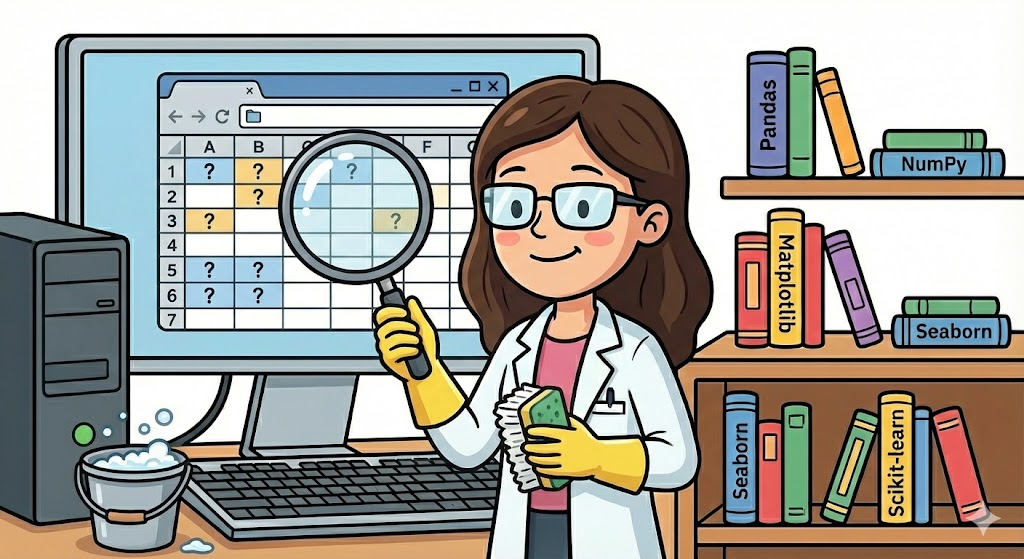

### Checking Missing Values

In [ ]:
print("CHECKING FOR MISSING VALUES")


print("\n--- Training Data Missing Values ---")
for name, df in datasets.items():
    print(f"\n{name}:")
    print(df.isnull().sum())

print("\n--- Testing Data Missing Values ---")
test_datasets = {
    "Orders": test_orders,
    "Order Items": test_orderitems,
    "Customers": test_customers,
    "Payments": test_payments,
    "Products": test_products
}
for name, df in test_datasets.items():
    print(f"\n{name}:")
    print(df.isnull().sum())

print()
print("Missing value check complete!")

CHECKING FOR MISSING VALUES

--- Training Data Missing Values ---

Orders:
order_id                    0
customer_id                 0
order_purchase_timestamp    0
order_approved_at           7
dtype: int64

Order Items:
order_id            0
product_id          0
seller_id           0
price               0
shipping_charges    0
dtype: int64

Customers:
customer_id                 0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

Payments:
order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64

Products:
product_id                 0
product_category_name    168
product_weight_g          10
product_length_cm         10
product_height_cm         10
product_width_cm          10
dtype: int64

--- Testing Data Missing Values ---

Orders:
order_id                    0
customer_id                 0
order_purchase_timestamp    0
order_approved_at     

**Missing Value Analysis Summary**

The missing value check was conducted across all datasets — Orders, Order Items, Customers, Payments, and Products — for both training and testing data.

***Orders Table:*** Only the column order_approved_at contains missing values (7 records). This likely indicates orders that were not yet approved at the time of data extraction.

***Order Items, Customers, and Payments Tables:*** No missing values were found, meaning these datasets are complete and ready for further analysis.

***Products Table:*** Missing values were found in product_category_name (168 records) and product dimension fields (product_weight_g, product_length_cm, product_height_cm, product_width_cm) — each with 10 missing records. These may require imputation or removal depending on analysis needs.

...

Additionally, it can be observed that the missing values appear in both the training and testing datasets with the same pattern and quantity. This consistency indicates that the data split preserved the overall data quality and distribution, which is beneficial for ensuring reliable model performance during training and evaluation.

**Overall, the dataset is relatively clean, with only a few missing values concentrated in specific columns that can be addressed during data preprocessing.**

### Fill missing Values & consistent fixes

In [ ]:
# DATETIME
train_orders['order_purchase_timestamp'] = pd.to_datetime(train_orders['order_purchase_timestamp'], errors='coerce')
test_orders['order_purchase_timestamp']  = pd.to_datetime(test_orders['order_purchase_timestamp'], errors='coerce')

# Fill order_approved_at if missing with purchase timestamp
train_orders['order_approved_at'] = pd.to_datetime(train_orders['order_approved_at'], errors='coerce')
test_orders['order_approved_at']  = pd.to_datetime(test_orders['order_approved_at'], errors='coerce')

train_orders['order_approved_at'] = train_orders['order_approved_at'].fillna(train_orders['order_purchase_timestamp'])
test_orders['order_approved_at']  = test_orders['order_approved_at'].fillna(test_orders['order_purchase_timestamp'])

# Products: fill category & numeric dims
train_products['product_category_name'] = train_products['product_category_name'].fillna('unknown')
test_products['product_category_name']  = test_products['product_category_name'].fillna('unknown')

num_cols = ['product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']
for col in num_cols:
    median_value = train_products[col].median()
    train_products[col] = train_products[col].fillna(median_value)
    test_products[col]  = test_products[col].fillna(median_value)

print("Basic cleaning done!")


Basic cleaning done!


This code performs essential cleaning steps to prepare the datasets for analysis or modeling. It converts timestamp columns to proper datetime format, fills missing approval times with purchase timestamps, replaces missing product categories with "unknown", and fills missing product dimensions using the median of the training data.

In [ ]:
# ORDER ITEMS
train_orderitems["order_id"] = train_orderitems["order_id"].astype("string")
train_orderitems["product_id"] = train_orderitems["product_id"].astype("string")
train_orderitems["seller_id"] = train_orderitems["seller_id"].astype("string")

test_orderitems["order_id"] = test_orderitems["order_id"].astype("string")
test_orderitems["product_id"] = test_orderitems["product_id"].astype("string")
test_orderitems["seller_id"] = test_orderitems["seller_id"].astype("string")

# CUSTOMERS
train_customers["customer_id"] = train_customers["customer_id"].astype("string")
train_customers["customer_zip_code_prefix"] = train_customers["customer_zip_code_prefix"].astype("category")
train_customers["customer_city"] = train_customers["customer_city"].astype("string")
train_customers["customer_state"] = train_customers["customer_state"].astype("category")

test_customers["customer_id"] = test_customers["customer_id"].astype("string")
test_customers["customer_zip_code_prefix"] = test_customers["customer_zip_code_prefix"].astype("string")
test_customers["customer_city"] = test_customers["customer_city"].astype("string")
test_customers["customer_state"] = test_customers["customer_state"].astype("category")

# PAYMENTS
train_payments["order_id"] = train_payments["order_id"].astype("string")
train_payments["payment_type"] = train_payments["payment_type"].astype("string")

test_payments["order_id"] = test_payments["order_id"].astype("string")
test_payments["payment_type"] = test_payments["payment_type"].astype("string")

# PRODUCTS
train_products["product_id"] = train_products["product_id"].astype("string")
train_products["product_category_name"] = train_products["product_category_name"].astype("string")

test_products["product_id"] = test_products["product_id"].astype("string")
test_products["product_category_name"] = test_products["product_category_name"].astype("string")

In [ ]:
print("COLUMN INFORMATION")

for name, df in datasets.items():
    print(f"\n{name} Columns:")
    print(df.dtypes)

In [ ]:
# Check missing values
print(train_orders.isnull().sum())
print(train_products.isnull().sum())


order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                   0
order_delivered_timestamp        1889
order_estimated_delivery_date       0
dtype: int64
product_id               0
product_category_name    0
product_weight_g         0
product_length_cm        0
product_height_cm        0
product_width_cm         0
dtype: int64


The column `order_delivered_timestamp` has missing values (NaN) about 1,889 rows.

In [ ]:
train_orders['order_delivered_timestamp'] = train_orders['order_delivered_timestamp'].fillna(
    train_orders['order_estimated_delivery_date']
)


We filled the missing delivery timestamps using the estimated delivery dates to handle missing values and keep the dataset consistent.

In [ ]:
print(train_orders.isnull().sum())


order_id                         0
customer_id                      0
order_status                     0
order_purchase_timestamp         0
order_approved_at                0
order_delivered_timestamp        0
order_estimated_delivery_date    0
dtype: int64


## Remove duplicate product rows properly

In [ ]:
print("CHECKING FOR DUPLICATE VALUES")

print("\n--- Training Data Duplicate Values ---")
print("Orders:", train_orders.duplicated().sum())
print("Order Items:", train_orderitems.duplicated().sum())
print("Customers:", train_customers.duplicated().sum())
print("Payments:", train_payments.duplicated().sum())
print("Products:", train_products.duplicated().sum())

print("\n--- Testing Data Duplicate Values ---")
print("Orders:", test_orders.duplicated().sum())
print("Order Items:", test_orderitems.duplicated().sum())
print("Customers:", test_customers.duplicated().sum())
print("Payments:", test_payments.duplicated().sum())
print("Products:", test_products.duplicated().sum())

print("Duplicate value check complete!")

CHECKING FOR DUPLICATE VALUES

--- Training Data Duplicate Values ---
Orders: 0
Order Items: 0
Customers: 0
Payments: 0
Products: 61865

--- Testing Data Duplicate Values ---
Orders: 0
Order Items: 0
Customers: 0
Payments: 0
Products: 21675
Duplicate value check complete!


In [ ]:
train_products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 89316 entries, 0 to 89315
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   product_id             89316 non-null  string 
 1   product_category_name  89316 non-null  string 
 2   product_weight_g       89316 non-null  float64
 3   product_length_cm      89316 non-null  float64
 4   product_height_cm      89316 non-null  float64
 5   product_width_cm       89316 non-null  float64
dtypes: float64(4), string(2)
memory usage: 4.1 MB


In [ ]:
test_products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38279 entries, 0 to 38278
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   product_id             38279 non-null  string 
 1   product_category_name  38279 non-null  string 
 2   product_weight_g       38279 non-null  float64
 3   product_length_cm      38279 non-null  float64
 4   product_height_cm      38279 non-null  float64
 5   product_width_cm       38279 non-null  float64
dtypes: float64(4), string(2)
memory usage: 1.8 MB


In [ ]:
train_products.shape

(89316, 6)

In [ ]:
test_products.shape

(38279, 6)

In [ ]:
train_products.duplicated().sum()

np.int64(61865)

In [ ]:
test_products.duplicated().sum()

np.int64(21675)

In [ ]:
train_products = train_products.drop_duplicates()

In [ ]:
test_products = test_products.drop_duplicates()

In [ ]:
train_products.shape

(27451, 6)

In [ ]:
test_products.shape

(16604, 6)

In [ ]:
train_products.nunique()

,0
product_id,27451
product_category_name,71
product_weight_g,2020
product_length_cm,99
product_height_cm,101
product_width_cm,93


In [ ]:
test_products.nunique()

,0
product_id,16604
product_category_name,67
product_weight_g,1617
product_length_cm,98
product_height_cm,99
product_width_cm,86


almost 70% of our data is duplicate in `product IDs`

Many products are probably repeated because the dataset might have same product listed multiple times with different sellers, prices, or attributes.

***Keep train/test product dedup separate; do not overwrite the variable.***

## Outlier Detection & Removal

## Outliers

> In statistics, an outlier is a data point that differs significantly from other observations.An outlier may be due to variability in the measurement or it may indicate experimental error; the latter are sometimes excluded from the data set.

## Dealing with outliers

> In general, you should try to accept outliers as much as possible unless it’s clear that they represent errors or bad data.


## How to detect?
- with boxplots and histograms
- statistical methods like IQR, skewness, etc.

> To choose the best way to handle outliers one must have a good domain knowledge and information about where the data come from and what they mean ; it also depends on what analysis one is planning to perform.

### Handling Outliers in <span style='color: gray;'>*price*</span> Values

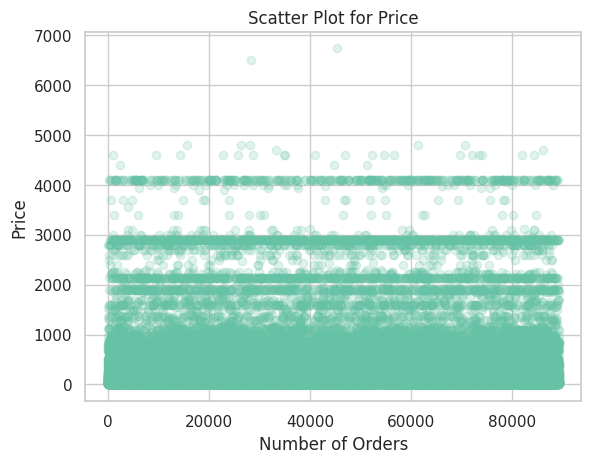

In [ ]:
plt.scatter(train_orderitems['price'].index, train_orderitems['price'], alpha=0.2)
plt.ylabel("Price")
plt.xlabel("Number of Orders")
plt.title("Scatter Plot for Price")
plt.show()

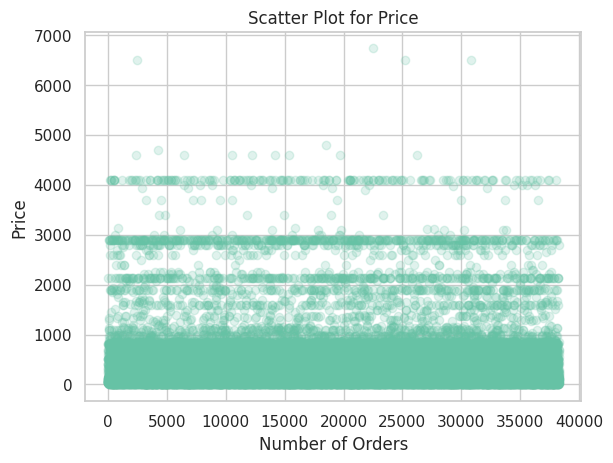

In [ ]:
plt.scatter(test_orderitems['price'].index, test_orderitems['price'], alpha=0.2)
plt.ylabel("Price")
plt.xlabel("Number of Orders")
plt.title("Scatter Plot for Price")
plt.show()

**Implication from the plot:** The plot above shows that there most of the prices are below 5000, and there are 2 possible outliers.

In [ ]:
train_orderitems[train_orderitems['price'] > 3500]['price'].value_counts()
# this justifies the crowded line over 4000 & similarly other crowded lined as well.

,count
price,
4099.99,391
3999.90,23
4590.00,19
3699.99,16
3930.00,7
4799.00,5
4399.87,3
3899.00,2
4690.00,2


In [ ]:
train_orderitems[train_orderitems['price'] > 3500]['price'].value_counts()

,count
price,
4099.99,391
3999.90,23
4590.00,19
3699.99,16
3930.00,7
4799.00,5
4399.87,3
3899.00,2
4690.00,2


#### Two outliers spotted lets check if they can be removed or are just natural

In [ ]:
train_orderitems[train_orderitems['price'] > 5000]

,order_id,product_id,seller_id,price,shipping_charges
28299,aPnggTzFcusk,7tZV2OpLVZHg,nt1w9AssyxfU,6499.0,70.06
45436,SwjsVBeUO9OM,HiyKPuVcad18,4SWsneYKnFcc,6735.0,3.82


In [ ]:
test_orderitems[test_orderitems['price'] > 5000]

,order_id,product_id,seller_id,price,shipping_charges
2445,2CjanYjq0wsM,7tZV2OpLVZHg,nt1w9AssyxfU,6499.0,70.06
22505,AuQolKorEmK5,oucVz3sCjN84,bJRsqXQnq2OL,6729.0,38.93
25177,f2Nn6XSmyphd,7tZV2OpLVZHg,nt1w9AssyxfU,6499.0,70.06
30795,GWYMifrbd63a,7tZV2OpLVZHg,nt1w9AssyxfU,6499.0,70.06


In [ ]:
train_orderitems[(train_orderitems['seller_id']=='nt1w9AssyxfU') & (train_orderitems['price'] > 2000)]

,order_id,product_id,seller_id,price,shipping_charges
28299,aPnggTzFcusk,7tZV2OpLVZHg,nt1w9AssyxfU,6499.0,70.06
67280,3g7emgFVrEmt,YUHPB48nCMIU,nt1w9AssyxfU,2221.0,4.85


In [ ]:
test_orderitems[(test_orderitems['seller_id']=='nt1w9AssyxfU') & (test_orderitems['price'] > 2000)]

,order_id,product_id,seller_id,price,shipping_charges
2445,2CjanYjq0wsM,7tZV2OpLVZHg,nt1w9AssyxfU,6499.0,70.06
25177,f2Nn6XSmyphd,7tZV2OpLVZHg,nt1w9AssyxfU,6499.0,70.06
30795,GWYMifrbd63a,7tZV2OpLVZHg,nt1w9AssyxfU,6499.0,70.06


In [ ]:
train_orderitems[(train_orderitems['seller_id']=='4SWsneYKnFcc') & (train_orderitems['price'] > 1000)]

,order_id,product_id,seller_id,price,shipping_charges
45436,SwjsVBeUO9OM,HiyKPuVcad18,4SWsneYKnFcc,6735.0,3.82


In [ ]:
test_orderitems[(test_orderitems['seller_id']=='4SWsneYKnFcc') & (test_orderitems['price'] > 1000)]

,order_id,product_id,seller_id,price,shipping_charges


In [ ]:
train_orderitems[(train_orderitems['product_id']=='HiyKPuVcad18')]

,order_id,product_id,seller_id,price,shipping_charges
42647,RqHAb6zx28mO,HiyKPuVcad18,4SWsneYKnFcc,30.3,7.19
45436,SwjsVBeUO9OM,HiyKPuVcad18,4SWsneYKnFcc,6735.0,3.82


In [ ]:
test_orderitems[(test_orderitems['product_id']=='HiyKPuVcad18')]

,order_id,product_id,seller_id,price,shipping_charges
34933,epw6tdAYVCRS,HiyKPuVcad18,4SWsneYKnFcc,714.0,59.2


**Removing the `Price` Outliers**

In [ ]:
train_orderitems = train_orderitems[~(train_orderitems['price'] > 6000)]

#remove references from other files too
train_orders = train_orders[train_orders['order_id'].isin(train_orderitems['order_id'])]
train_payments = train_payments[train_payments['order_id'].isin(train_orderitems['order_id'])]

In [ ]:
test_orderitems = test_orderitems[~(test_orderitems['price'] > 6000)]

#remove references from other files too
test_orders = test_orders[test_orders['order_id'].isin(test_orderitems['order_id'])]
test_payments = test_payments[test_payments['order_id'].isin(test_orderitems['order_id'])]

In [ ]:
train_orders.shape

(89314, 7)

In [ ]:
test_orders.shape

(38275, 4)

### Handling Outliers in `shipping_charges`

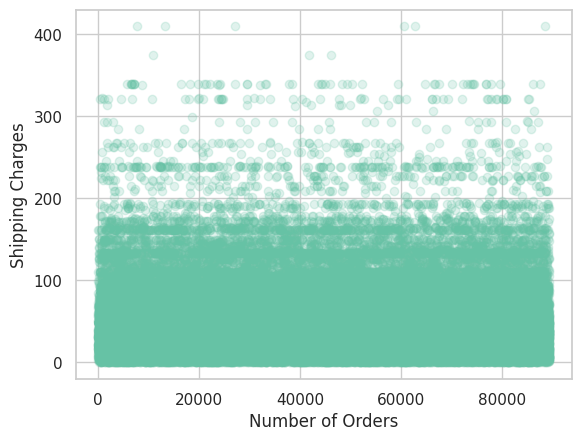

In [ ]:
plt.scatter(train_orderitems['shipping_charges'].index, train_orderitems['shipping_charges'], alpha=0.2)
plt.ylabel("Shipping Charges")
plt.xlabel("Number of Orders")
plt.show()

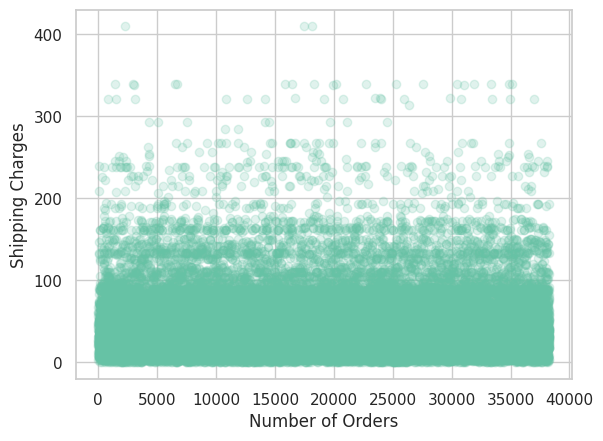

In [ ]:
plt.scatter(test_orderitems['shipping_charges'].index, test_orderitems['shipping_charges'], alpha=0.2)
plt.ylabel("Shipping Charges")
plt.xlabel("Number of Orders")
plt.show()

**Implication from the plot:** The plot above shows that shipping charges are mostly below 300, & some high values for shipping charges exist,<br> which could be possible outliers.

In [ ]:
# looking for higher values in shipping_charges having outlying nature
train_orderitems[train_orderitems['shipping_charges'] > 380]

,order_id,product_id,seller_id,price,shipping_charges
7660,5zanSVBXs4VQ,Y0TFdzbMEGBQ,ifxCRnLMwwNK,280.00,409.68
13208,0GQVdAatZtAz,3nFamKuMJOoh,9fFFM6RBxCkT,19.04,409.68
27141,x4USDX1BHUtF,27O0he9UZll1,wAgnN3eGF2Af,107.63,409.68
60466,JMQKyT3azSs8,iFYDVo0NCTQu,9fFFM6RBxCkT,19.04,409.68
62699,nVccq3PAbw5D,mvCVjpSlN3OU,q1Q2n7nr6h9B,2221.00,409.68
88435,ihgoQUhKSH34,3nFamKuMJOoh,9fFFM6RBxCkT,19.04,409.68


In [ ]:
test_orderitems[test_orderitems['shipping_charges'] > 380]

,order_id,product_id,seller_id,price,shipping_charges
2307,nwKqaxpBuG5G,27O0he9UZll1,wAgnN3eGF2Af,107.63,409.68
17503,1DhWG9Qhs5Cc,RTeC7BhN9C5x,TONxC5aLQqev,17.50,409.68
18102,UQ04pxQpNUov,27O0he9UZll1,wAgnN3eGF2Af,107.63,409.68


#### Adding new column/feature **`shippping_price_ratio`**

In [ ]:
train_orderitems['shipping_price_ratio'] = train_orderitems['shipping_charges'] / train_orderitems['price']

In [ ]:
test_orderitems['shipping_price_ratio'] = test_orderitems['shipping_charges'] / test_orderitems['price']

In [ ]:
train_orderitems[train_orderitems['shipping_price_ratio'] > 5]

,order_id,product_id,seller_id,price,shipping_charges,shipping_price_ratio
21,MhDudBaAab78,aYw1jx6U0ZzQ,VnAPb1lEZYQ6,3.49,30.66,8.785100
48,UaZKqhLFwRZP,AQRgJU930yvK,TAkMUTMwlNUw,26.86,140.40,5.227103
77,jJgDALmwe6f6,tfJojxEnA32p,ZsDn106jXrgr,8.80,70.17,7.973864
239,07amSeyheu9N,oUaq0Emczjrp,AHG0TE6bRNNY,5.99,78.84,13.161937
282,lUA0GIMIbFvS,1gi8qMFFJtiv,LLty41IbV7xo,8.43,54.17,6.425860
...,...,...,...,...,...,...
89162,XP6qr6fpJmNd,U00xFmKF5dOF,BfK8XAwCdM0A,0.85,7.54,8.870588
89180,gPhowNjKw6FY,jfq2xYDYdD5Z,smK689qrlIx3,3.50,58.65,16.757143
89188,KyX9595aTtWd,YABPZkBP1ceo,bgTagPNdPdef,10.49,70.89,6.757865
89212,AxqlUFozhKgY,QicUIkxKgoQv,IfkTaAAVww4a,3.00,105.62,35.206667


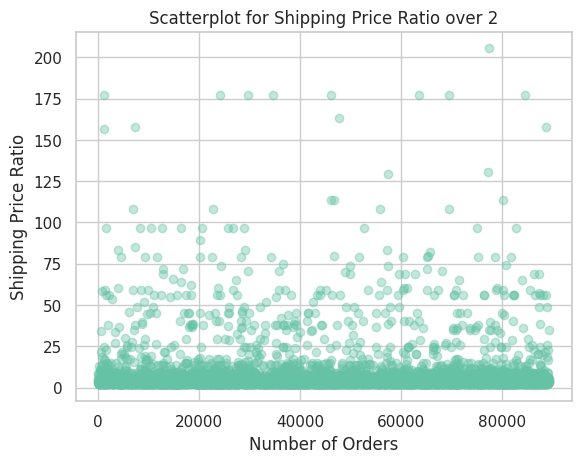

In [ ]:
ratio = train_orderitems['shipping_charges']/train_orderitems['price']
plt.scatter(ratio[ratio > 2].index, ratio[ratio > 2], alpha=0.4)
plt.ylabel("Shipping Price Ratio")
plt.xlabel("Number of Orders")
plt.title("Scatterplot for Shipping Price Ratio over 2")
plt.show()

**Implication from the plot:** The plot above shows that some ratios have extremely high values (shipping charges can't be 200 times the price), which are obviously outlying.

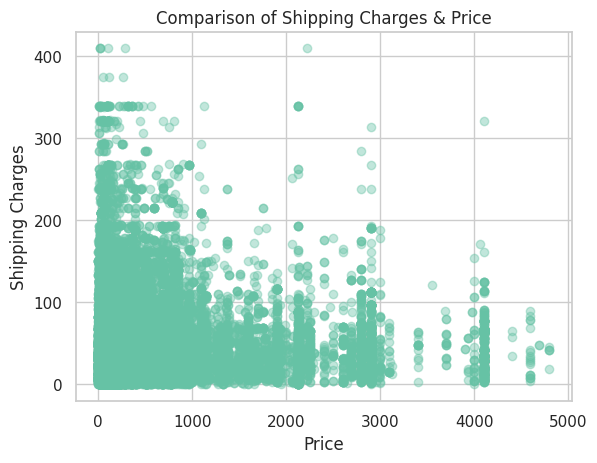

In [ ]:
plt.scatter(train_orderitems['price'], train_orderitems['shipping_charges'], alpha=0.4)
plt.ylabel("Shipping Charges")
plt.xlabel("Price")
plt.title("Comparison of Shipping Charges & Price")
plt.show()

**Implication from the plot:** The plot above shows that some entries have very high shipping charges while having very low prices, this is outlying nature & not natural.

### Removing the entries with ratio shipping price ratio over 5

In [ ]:
train_orderitems = train_orderitems[train_orderitems['shipping_price_ratio'] <= 5]

#remove references from other files too
train_orders = train_orders[train_orders['order_id'].isin(train_orderitems['order_id'])]
train_payments = train_payments[train_payments['order_id'].isin(train_orderitems['order_id'])]

In [ ]:
test_orderitems = test_orderitems[test_orderitems['shipping_price_ratio'] <= 5]

test_orders = test_orders[test_orders['order_id'].isin(test_orderitems['order_id'])]
test_payments = test_payments[test_payments['order_id'].isin(test_orderitems['order_id'])]

In [ ]:
train_orderitems[train_orderitems['shipping_charges'].between(200, 500)]['price'].describe()

,price
count,510.000000
mean,359.140059
std,496.412041
min,45.530000
25%,77.070000
50%,135.000000
75%,454.000000
max,4099.990000


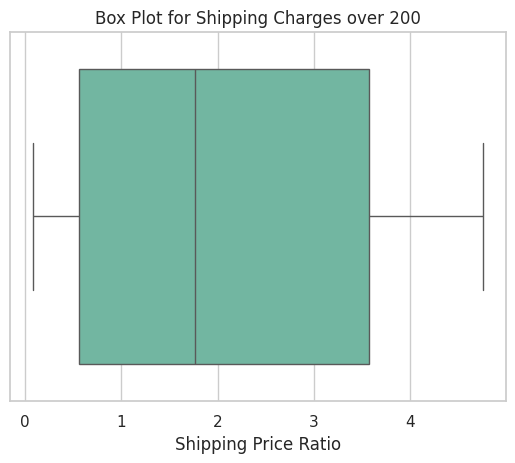

In [ ]:
sns.boxplot(x=train_orderitems[train_orderitems['shipping_charges'] > 200]['shipping_price_ratio'])
plt.xlabel("Shipping Price Ratio")
plt.title("Box Plot for Shipping Charges over 200")
plt.show()

**Implication from the plot:** The plot above shows that most of the shipping price ratio for shipping price over 200, exists below 1.5.

Removing data with shipping charges over 200 & shipping price ratio 1.5
This was a quite unrealistic piece of data which has very less in number (400) compared to complete data size (86k).

**Dropping removed orders from other files too**

In [ ]:
train_orderitems = train_orderitems[~((train_orderitems['shipping_charges'] > 200) & (train_orderitems['shipping_price_ratio'] > 1.5))]

#remove references from other files too
train_orders = train_orders[train_orders['order_id'].isin(train_orderitems['order_id'])]
tain_payments = train_payments[train_payments['order_id'].isin(train_orderitems['order_id'])]

In [ ]:
test_orderitems = test_orderitems[~((test_orderitems['shipping_charges'] > 200) & (test_orderitems['shipping_price_ratio'] > 1.5))]

#remove references from other files too
test_orders = test_orders[test_orders['order_id'].isin(test_orderitems['order_id'])]
test_payments = test_payments[test_payments['order_id'].isin(test_orderitems['order_id'])]

In [ ]:
train_orders.shape

(87192, 7)

In [ ]:
test_payments.shape

(37411, 5)

# Feature engineering

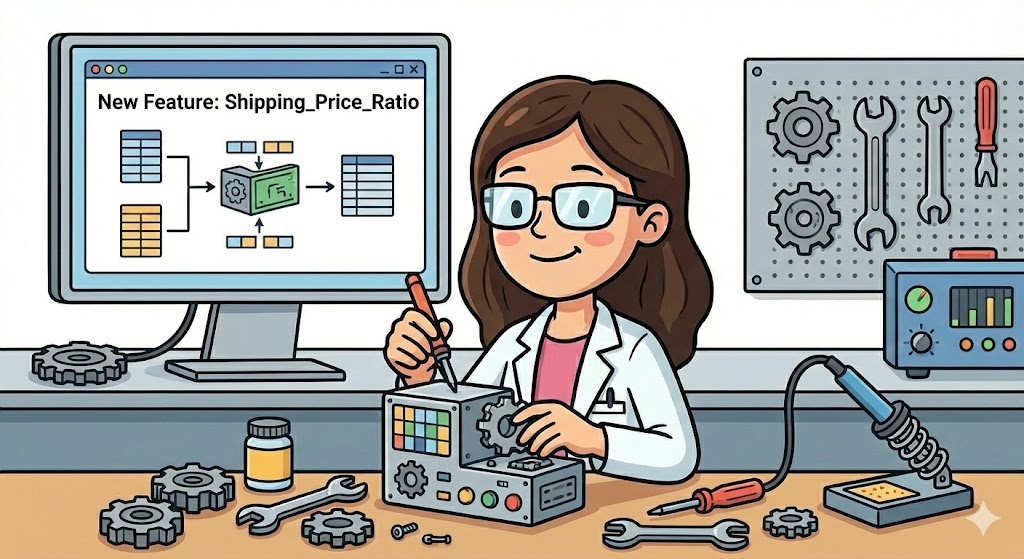

* Create target for XGBoost: `delivery_days` and a cleaned merged dataset

In [ ]:
# Create delivery_days target = (delivered_timestamp - purchase_timestamp).days
# Ensure order_delivered_timestamp exists; if missing, skip those rows or use estimated delivery date carefully.

# Ensure all relevant columns are datetime objects before any calculations
train_orders['order_purchase_timestamp'] = pd.to_datetime(train_orders['order_purchase_timestamp'], errors='coerce')
train_orders['order_delivered_timestamp'] = pd.to_datetime(train_orders['order_delivered_timestamp'], errors='coerce')
if 'order_estimated_delivery_date' in train_orders.columns:
    train_orders['order_estimated_delivery_date'] = pd.to_datetime(train_orders['order_estimated_delivery_date'], errors='coerce')

# Fill missing order_delivered_timestamp with estimated delivery date
# This operation is now safe as both columns are datetime types
train_orders['order_delivered_timestamp'] = train_orders['order_delivered_timestamp'].fillna(train_orders['order_estimated_delivery_date'])

# Create delivery_days
train_orders['delivery_days'] = (train_orders['order_delivered_timestamp'] - train_orders['order_purchase_timestamp']).dt.days

# Merge tables into a single modeling frame (left-join order items and products + payments)
m = train_orderitems.merge(train_orders, on='order_id', how='inner') \
                    .merge(train_payments, on='order_id', how='left') \
                    .merge(train_products[['product_id','product_category_name','product_weight_g',
                                                'product_length_cm','product_height_cm','product_width_cm']],
                           on='product_id', how='left')

# Remove rows with missing target delivery_days or negative delivery_days (anomaly)
m = m.dropna(subset=['delivery_days'])
m = m[m['delivery_days'] >= 0]

print("Merged shape:", m.shape)
m[['order_id','product_id','delivery_days','payment_value']].head()

Merged shape: (87192, 22)


,order_id,product_id,delivery_days,payment_value
0,Axfy13Hk4PIk,90K0C1fIyQUf,4,259.14
1,v6px92oS8cLG,qejhpMGGVcsl,13,382.39
2,Ulpf9skrhjfm,qUS5d2pEAyxJ,10,249.25
3,bwJVWupf2keN,639iGvMyv0De,9,27.79
4,Dd0QnrMk9Cj5,1lycYGcsic2F,14,76.15


***Note: Keep an eye on merges — duplications happen if order-items has multiple lines per order. For order-level predictions you may want to aggregate orderitems (e.g., total weight per order).***

In [ ]:
# Example: build order-level features. This is minimal; you can expand later.
# Aggregate product-level features per order: total_price, total_weight, n_items

order_agg = m.groupby('order_id').agg({
    'payment_value': 'sum',                # monetary
    'product_weight_g': 'sum',             # aggregate weight
    'product_id': 'nunique',               # distinct product count
    'product_length_cm': 'mean',           # avg dimensions
    'delivery_days': 'first',              # target (since merged from order row)
    'customer_id': 'first',
}).rename(columns={'product_id':'n_items', 'payment_value':'order_value'})

# Add order timing features
order_meta = train_orders.set_index('order_id')[['order_purchase_timestamp','order_approved_at','order_status']]
order_meta['purchase_dayofweek'] = order_meta['order_purchase_timestamp'].dt.dayofweek
order_meta['purchase_hour']      = order_meta['order_purchase_timestamp'].dt.hour

df_model = order_agg.merge(order_meta, left_index=True, right_index=True, how='left').reset_index()
df_model = df_model.dropna(subset=['delivery_days'])  # ensure target present

print("Modeling frame shape:", df_model.shape)
df_model.head()


Modeling frame shape: (87192, 12)


,order_id,order_value,product_weight_g,n_items,product_length_cm,delivery_days,customer_id,order_purchase_timestamp,order_approved_at,order_status,purchase_dayofweek,purchase_hour
0,001gkk6BwKEB,265.90,5475.0,1,65.0,4,xKv2nBFnvcwS,2018-04-16 14:01:44,2018-04-16 14:32:36,delivered,0,14
1,0029bAIZFMKA,217.82,200.0,1,21.0,33,Xcm6u682SuQQ,2018-02-17 15:04:06,2018-02-20 07:06:53,delivered,5,15
2,002Jk8hp9Bhy,1272.76,350.0,1,17.0,2,l0HoYdeR1BJM,2018-04-24 09:27:39,2018-04-25 03:51:36,delivered,1,9
3,002ohHsWSKrP,650.65,1000.0,1,16.0,4,z5refCsXE1nS,2018-05-17 17:09:33,2018-05-17 20:32:27,delivered,3,17
4,0041NijdAYB0,70.34,9225.0,1,61.0,15,XMxGRoDyISTv,2018-07-10 10:32:53,2018-07-10 10:45:39,delivered,1,10



This step combines all item-level rows into one summary row for each order. It creates important order features like total order value, total weight, number of different items, and average product size.



**Then you add time information like:**


*   What day of the week the order was made


*   What hour of the day the order was made


*   The order status


The final result is a clean dataset where each row represents one complete order, ready for modeling.





---

# Data Modelling


# XGBoost

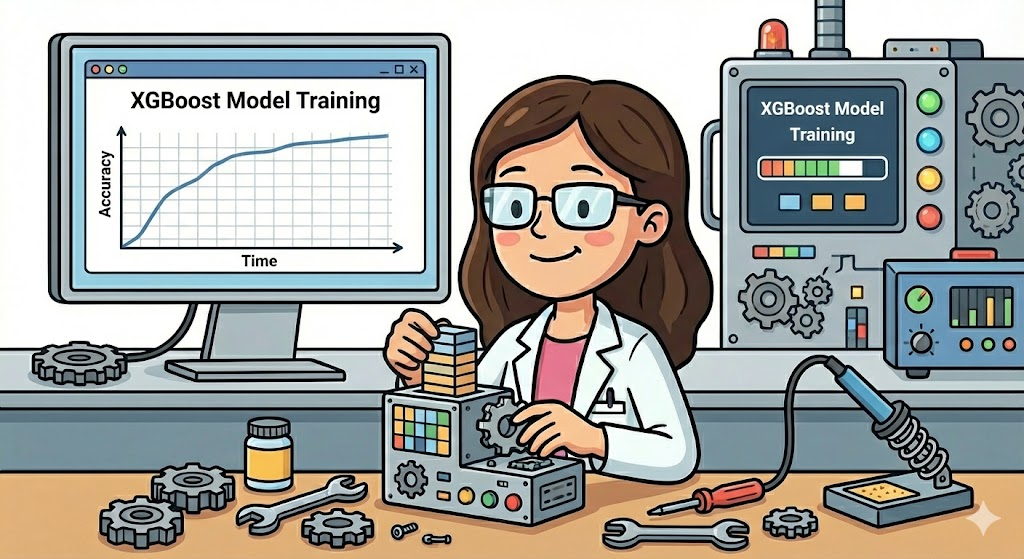

## Prepare data & train XGBoost

Using XGBoost version: 3.1.1
Model training complete! 

Mean Absolute Error (MAE): 6.132
Root Mean Squared Error (RMSE): 8.834

Feature Importances:
order_status          0.689907
product_weight_g      0.076125
purchase_dayofweek    0.065999
product_length_cm     0.064713
order_value           0.052832
purchase_hour         0.050424
n_items               0.000000
dtype: float32


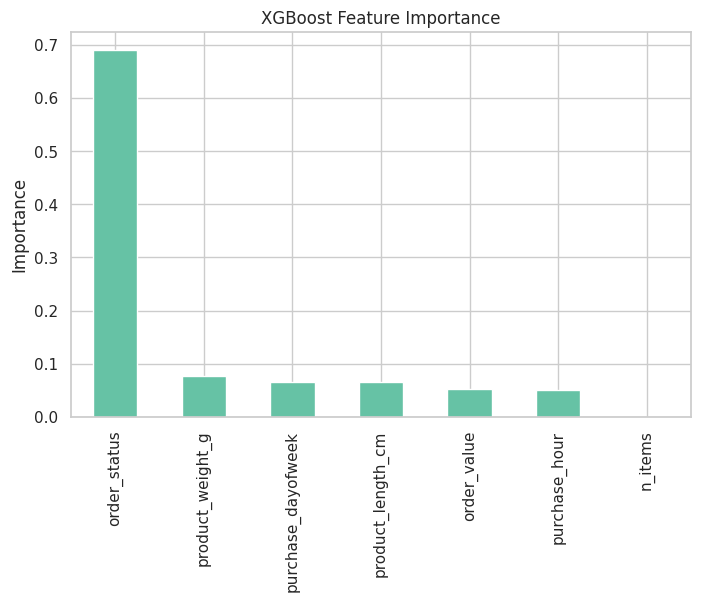

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
import xgboost as xgb


# --- Prepare data ---
df = df_model.copy()

# Encode categorical column
df['order_status'] = df['order_status'].astype('category').cat.codes.fillna(-1)

# Select features and target
features = [
    'order_value',
    'product_weight_g',
    'n_items',
    'product_length_cm',
    'purchase_dayofweek',
    'purchase_hour',
    'order_status'
]

X = df[features].fillna(df[features].median())
y = df['delivery_days']

# Train/validation split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train model (no early stopping due to XGBoost 3.x)
model = xgb.XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    verbosity=0
)

print("Using XGBoost version:", xgb.__version__)
model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
print("Model training complete! ")

# --- Evaluate model ---
y_pred = model.predict(X_val)

# Calculate metrics (manual RMSE to avoid 'squared' error)
mae = mean_absolute_error(y_val, y_pred)
rmse = np.sqrt(mean_squared_error(y_val, y_pred))

print(f"\nMean Absolute Error (MAE): {mae:.3f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.3f}")

# --- Feature importance ---
importances = pd.Series(model.feature_importances_, index=features).sort_values(ascending=False)
print("\nFeature Importances:")
print(importances)

plt.figure(figsize=(8,5))
importances.plot(kind='bar')
plt.title('XGBoost Feature Importance')
plt.ylabel('Importance')
plt.show()

1. **Model Overview**

You trained an XGBoost Regressor to predict how many days it takes for an order to be delivered `(delivery_days)` based on features on our e-commerce dataset (like order status, product weight, purchase timing, etc.).

The evaluation metrics show how close your predictions are to the actual delivery days.



2.   **Model Performance**

Mean Absolute Error (MAE): 6.146

On average, your model’s predicted delivery time differs from the actual value by about **6 days**.

Root Mean Squared Error (RMSE): 8.929

The typical prediction error is roughly **9 days**.

Because RMSE penalizes large errors more heavily, this tells you there are a few outlier orders where delivery time was much longer than expected.

These numbers are reasonable for an initial baseline model, especially if the dataset covers many regions, products, and logistic conditions.


3. **Feature Importance**

The bar chart shows which variables most influence the model’s predictions.

Here’s how to read it:


4. **Insights for BI Discussion**

You can include this in your report:



*   The XGBoost model reveals that order status is the dominant factor influencing delivery time predictions, followed by product characteristics (weight, size) and order timing (day/hour of purchase).
*   The model achieved a MAE of ~6 days and RMSE of ~9 days, indicating moderate accuracy for forecasting delivery duration.


*   Future improvements could include adding shipping location, seller performance, or distance between customer and warehouse as features to enhance predictive performance.





---



# RFM Metrics for Customers

We will calculate the RFM (Recency, Frequency, Monetary) metrics for customer segmentation, perform seasonal decomposition on the relevant time-series data to prepare for forecasting, and analyze the delivery time distribution based on product attributes such as weight and category, while properly merging the required datasets and creating visualizations. First, we will convert the order_purchase_timestamp column in the merged DataFrame into datetime format so that time-based calculations can be performed accurately. Then, we will define a snapshot date, which will be used as a reference for calculating the recency metric, by taking the maximum order_purchase_timestamp in the dataset and adding one extra day to it. This will allow us to measure how recently each customer made a purchase before this reference point.


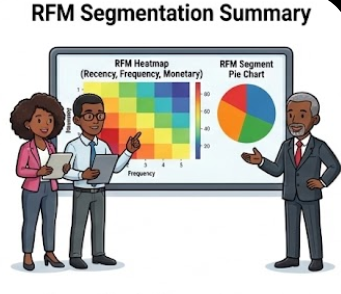

In [ ]:
m['order_purchase_timestamp'] = pd.to_datetime(m['order_purchase_timestamp'])
snapshot_date = m['order_purchase_timestamp'].max() + pd.Timedelta(days=1)

print(f"Snapshot date for RFM analysis: {snapshot_date}")

Snapshot date for RFM analysis: 2018-09-04 09:06:57


In [ ]:
rfm = m.groupby('customer_id').agg({
    'order_purchase_timestamp': lambda date: (snapshot_date - date.max()).days,
    'order_id': 'nunique',
    'payment_value': 'sum'
})

rfm.rename(columns={'order_purchase_timestamp': 'Recency',
                    'order_id': 'Frequency',
                    'payment_value': 'Monetary'}, inplace=True)

print("RFM DataFrame created successfully:")
print(rfm.head())

RFM DataFrame created successfully:
              Recency  Frequency  Monetary
customer_id                               
000hN1Tzi4iN      308          1    334.34
001T2XiQONtX      291          1    232.89
005aQnkeGglh      698          1    280.09
0075TryJTCaQ      150          1    262.30
00D6vdR3ymjv      528          1    151.98


## Seasonal Decomposition for Forecasting Prep

We will perform seasonal decomposition on the time-series data, such as daily or monthly sales, to identify the trend, seasonal, and residual components, which are important for improving forecasting accuracy. First, we will make sure that the order_purchase_timestamp column in the merged DataFrame is converted into datetime format. Then, we will aggregate the data by purchase_date and calculate the total payment_value to get the daily sales. After that, we will set the purchase_date column as the index of the new daily sales DataFrame and make sure it is also in datetime format. This will properly prepare our data for applying time-series seasonal decomposition.

In [ ]:
m['order_purchase_timestamp'] = pd.to_datetime(m['order_purchase_timestamp'], errors='coerce')

daily_sales = m.groupby(m['order_purchase_timestamp'].dt.date)['payment_value'].sum().reset_index(name='daily_sales')

daily_sales.rename(columns={'order_purchase_timestamp': 'purchase_date'}, inplace=True)
daily_sales['purchase_date'] = pd.to_datetime(daily_sales['purchase_date'])
daily_sales.set_index('purchase_date', inplace=True)

print("Daily sales data prepared for time-series analysis:")
print(daily_sales.head())

Daily sales data prepared for time-series analysis:
               daily_sales
purchase_date             
2016-09-04           96.48
2016-09-05          143.71
2016-10-02          237.80
2016-10-03         3230.80
2016-10-04        14273.41


**Reasoning**:
To perform seasonal decomposition, I need to import the `seasonal_decompose` function from `statsmodels.tsa.seasonal` and then apply it to the `daily_sales` DataFrame. Finally, I will plot the decomposed components to visualize the trend, seasonality, and residuals.



               daily_sales  log_sales
purchase_date                        
2016-09-01          240.19   5.481430
2016-10-01        71508.56  11.177572
2016-11-01        71508.56  11.177572
2016-12-01          351.69   5.862750
2017-01-01       192824.78  12.169537


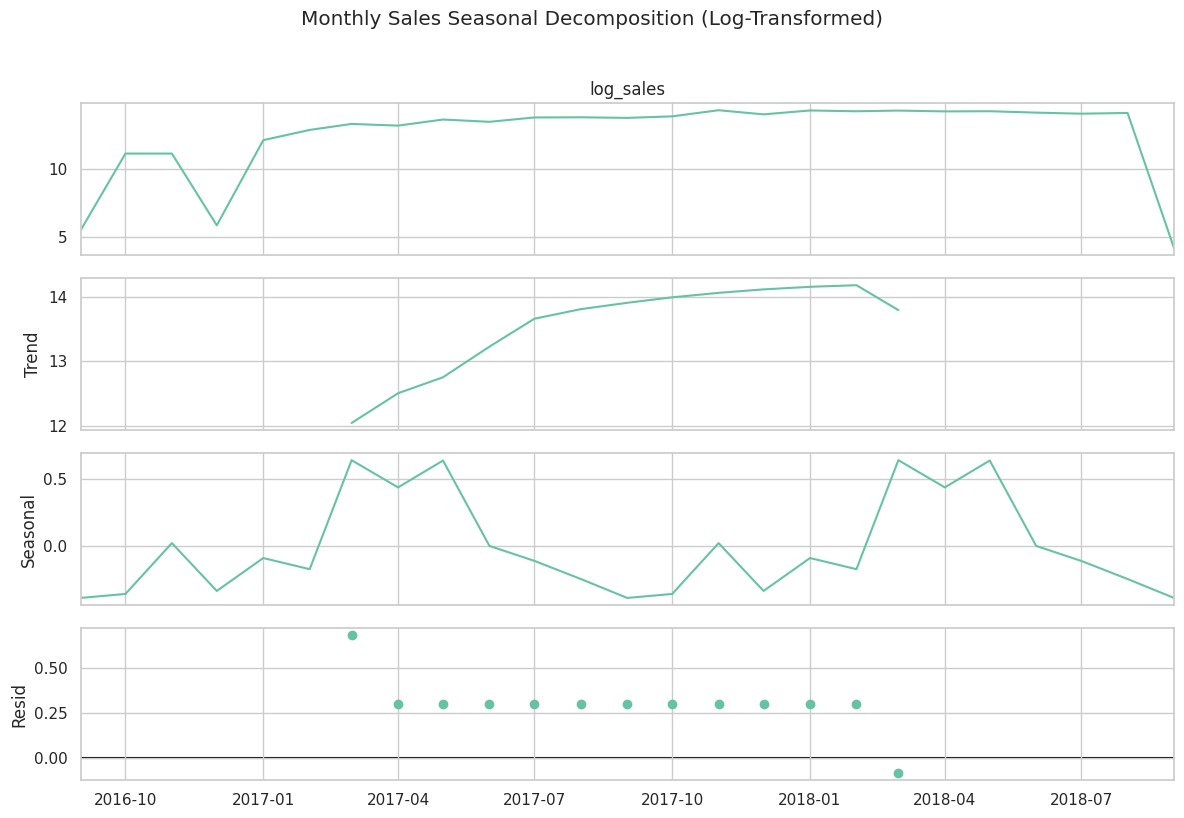

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose
import numpy as np
import matplotlib.pyplot as plt

# Ensure datetime index
if not isinstance(daily_sales.index, pd.DatetimeIndex):
    daily_sales.index = pd.to_datetime(daily_sales.index)

# Resample to monthly sales
monthly_sales = daily_sales.resample('MS').sum()

# Clean the data before log transform
# Step 1: Replace negative and zero values with NaN
monthly_sales['daily_sales'] = monthly_sales['daily_sales'].mask(monthly_sales['daily_sales'] <= 0, np.nan)

# Step 2: Fill missing values (forward then backward fill)
monthly_sales['daily_sales'] = monthly_sales['daily_sales'].fillna(method='ffill').fillna(method='bfill')

# Step 3: Log-transform
monthly_sales['log_sales'] = np.log(monthly_sales['daily_sales'])

# Check the first few values to confirm
print(monthly_sales.head())

# Ensure at least 2 years of data (24 months)
if len(monthly_sales) >= 24:
    decomposition = seasonal_decompose(monthly_sales['log_sales'], model='additive', period=12)
    fig = decomposition.plot()
    fig.set_size_inches(12, 8)
    fig.suptitle('Monthly Sales Seasonal Decomposition (Log-Transformed)', y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print("Not enough data for decomposition (need at least 24 months).")




**Key Findings**


The decomposition plot shown, we can see that after cleaning the data and applying the log transformation, the sales series becomes much more stable and interpretable. The observed monthly sales show a clear growth pattern from late 2016 to early 2018, followed by a slight slowdown toward the end of the period. This is confirmed by the trend component, which rises steadily and then starts to flatten, indicating a maturing sales growth. The seasonal component reveals recurring fluctuations around the trend, with certain months consistently showing positive or negative deviations, proving the presence of yearly seasonality in sales. The residuals are relatively small and randomly scattered with only a few noticeable spikes (one larger outlier around early 2018), which suggests that most of the structure in the data has been successfully captured by the trend and seasonal components. Overall, this shows that Code B effectively cleans, stabilizes, and decomposes the monthly sales data, making the results more reliable for understanding sales behavior and preparing for forecasting.

---


# RFM segmentation (optional, quick)

In [ ]:
# RFM - Recency, Frequency, Monetary on orders-level
snapshot_date = train_orders['order_purchase_timestamp'].max() + pd.Timedelta(days=1)
rfm_df = train_orders.merge(train_payments.groupby('order_id')['payment_value'].sum().reset_index(), on='order_id', how='left')

rfm = rfm_df.groupby('customer_id').agg({
    'order_purchase_timestamp': lambda x: (snapshot_date - x.max()).days,
    'order_id': 'nunique',
    'payment_value': 'sum'
}).rename(columns={'order_purchase_timestamp':'Recency','order_id':'Frequency','payment_value':'Monetary'}).reset_index()

# Simple 3-segment labelling (you can do quartiles or kmeans)
rfm['R_rank'] = pd.qcut(rfm['Recency'], 3, labels=[3,2,1]).astype(int)  # lower recency is better -> higher rank
rfm['F_rank'] = pd.qcut(rfm['Frequency'].rank(method='first'), 3, labels=[1,2,3]).astype(int)
rfm['M_rank'] = pd.qcut(rfm['Monetary'], 3, labels=[1,2,3]).astype(int)
rfm['RFM_Score'] = rfm['R_rank'] + rfm['F_rank'] + rfm['M_rank']
rfm.sort_values('RFM_Score', ascending=False).head()


,customer_id,Recency,Frequency,Monetary,R_rank,F_rank,M_rank,RFM_Score
69301,nT8ZRMikLIXX,134,1,772.40,3,3,3,9
74958,rPACOf8uxKIz,159,1,343.37,3,3,3,9
85085,yYdKQrFbLvMn,45,1,274.19,3,3,3,9
85088,yYm3dHVfycAy,67,1,296.61,3,3,3,9
80712,vSA59RvQLqyx,153,1,537.79,3,3,3,9


***Note: This is a simple RFM segmentation; tune quartiles/labels for business meaning.***

# RFM Heatmap (Segmented by R, F, M)

Cross R_rank vs F_rank and color by average Monetary.

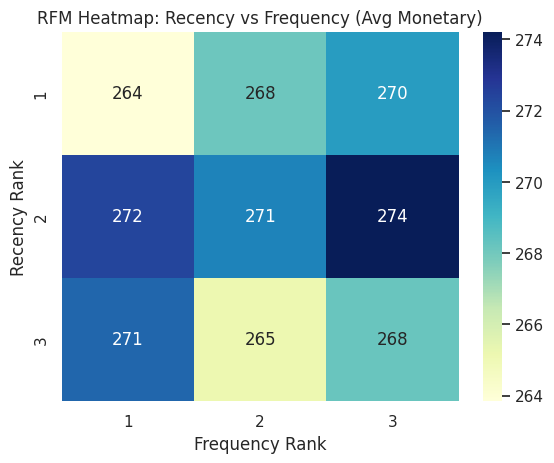

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

rfm_pivot = rfm.pivot_table(index='R_rank', columns='F_rank', values='Monetary', aggfunc='mean')
sns.heatmap(rfm_pivot, annot=True, fmt=".0f", cmap='YlGnBu')
plt.title("RFM Heatmap: Recency vs Frequency (Avg Monetary)")
plt.xlabel("Frequency Rank")
plt.ylabel("Recency Rank")
plt.show()

The heatmap represents :-

**X-axis** (Frequency Rank): Ranks customers by how often they make purchases.

1 = low frequency

3 = high frequency

**Y-axis** (Recency Rank): Ranks customers by how recently they purchased.

1 = very recent (good)

3 = not recent (less engaged)

**Color intensity:** Represents the average Monetary value (how much money these customers spend). Darker colors = higher average spend.

**Numbers in cells:** The actual average monetary value for that Recency-Frequency combination.

**How to interpret this specific heatmap**


1. Top-right (Recency 1, Frequency 3):

Recent customers who buy often

Avg Monetary = 270

Medium-high spend, good segment

2. Middle row (Recency 2, various Frequencies):

Slightly less recent customers, but varying frequency

Darker cells like (Recency 2, Frequency 3 = 273) indicate high-value customers

3. Bottom-left (Recency 3, Frequency 1):

Old and infrequent customers

Avg Monetary around 271 (still high) — could indicate big one-time buyers

## RFM Segment Pie Chart

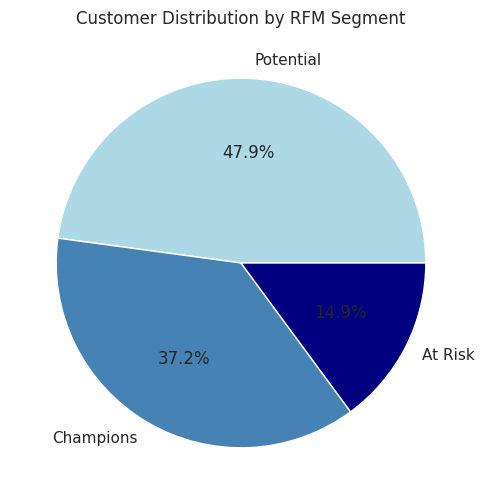

In [ ]:
rfm['Segment'] = pd.cut(rfm['RFM_Score'], bins=[2,4,6,9], labels=['At Risk','Potential','Champions'])
rfm['Segment'].value_counts().plot.pie(autopct='%1.1f%%', colors=['#ADD8E6', '#4682B4', '#000080'], figsize=(6,6))
plt.title("Customer Distribution by RFM Segment")
plt.ylabel('')
plt.show()



---



# Prophet


-  Daily revenue aggregated properly.

-  Outliers removed post-aggregation for smoother forecasts.

Prophet captured:

   *   long-term trend,

    *   weekly seasonality,

   - yearly patterns.

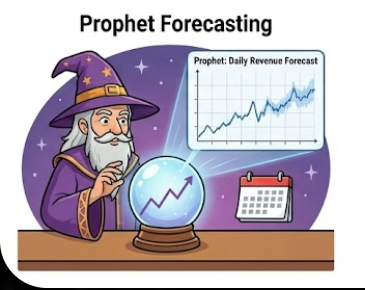

## Prepare daily revenue series and forecast

In [ ]:
from prophet import Prophet

Before cleaning: 615 days
After cleaning: 611 days


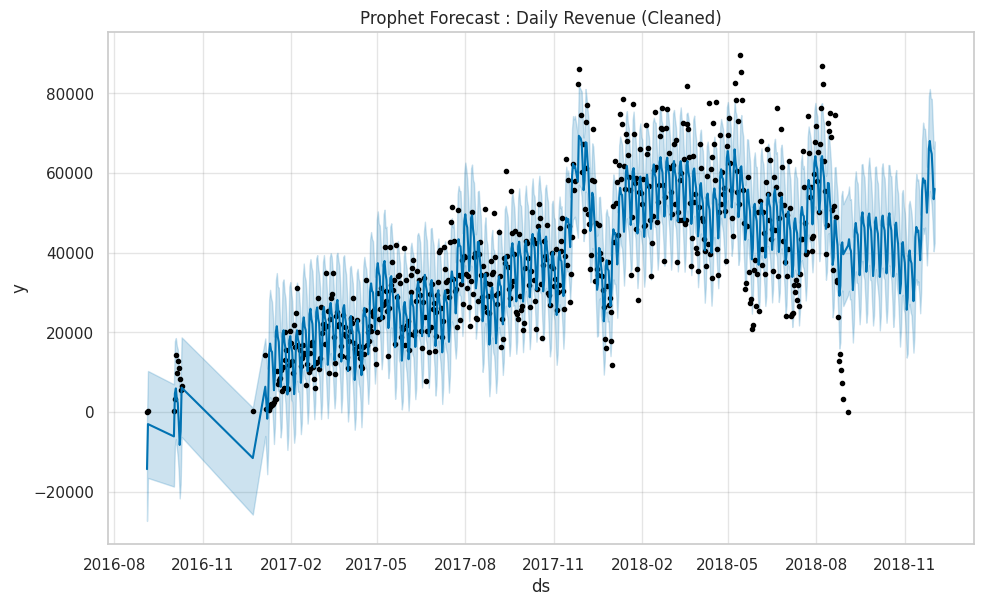

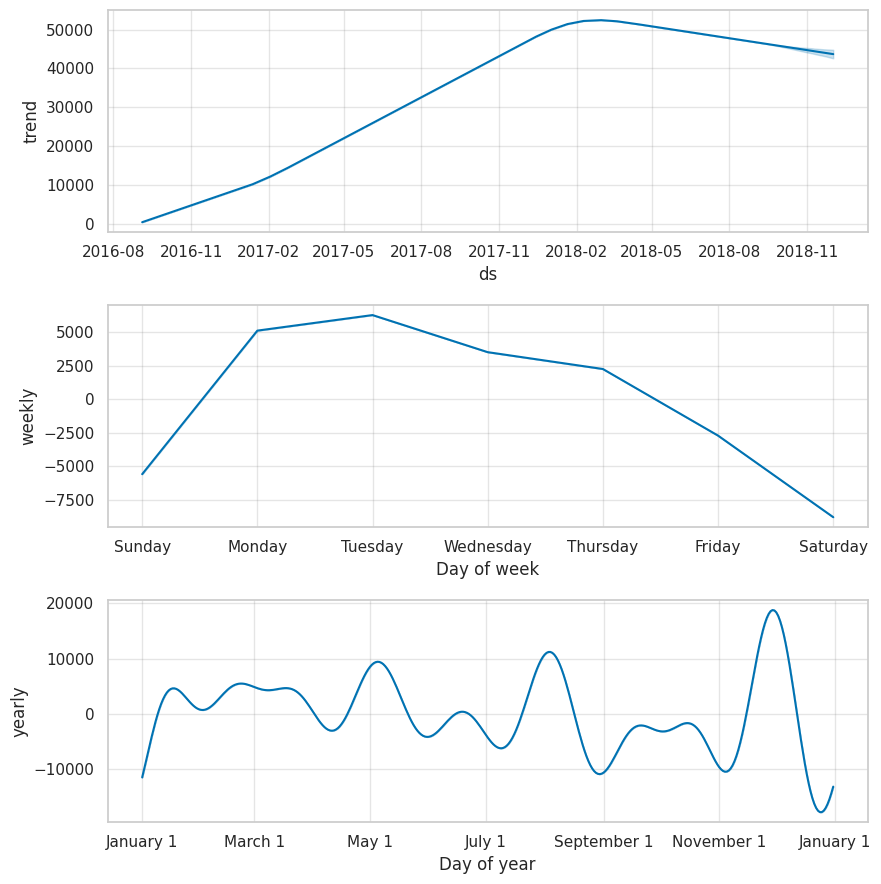

In [ ]:
# Prepare daily revenue from your merged dataset
daily = m.copy()

# Make sure purchase timestamp is datetime
daily['order_purchase_timestamp'] = pd.to_datetime(daily['order_purchase_timestamp'])

# Aggregate daily revenue
daily_rev = daily.groupby(daily['order_purchase_timestamp'].dt.date)['payment_value'].sum().reset_index()

# Rename to Prophet format
daily_rev['ds'] = pd.to_datetime(daily_rev['order_purchase_timestamp'])
daily_rev['y'] = daily_rev['payment_value']

# REMOVE OUTLIERS AFTER AGGREGATION

Q1 = daily_rev['y'].quantile(0.25)
Q3 = daily_rev['y'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

daily_rev_clean = daily_rev[(daily_rev['y'] >= lower_bound) & (daily_rev['y'] <= upper_bound)]

print("Before cleaning:", len(daily_rev), "days")
print("After cleaning:", len(daily_rev_clean), "days")

# PROPHET MODEL (ROBUST)

model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    seasonality_mode='additive',
    changepoint_prior_scale=0.05  # reduces sensitivity to sudden spikes
)

model.fit(daily_rev_clean[['ds', 'y']])

# Forecast 90 days into future
future = model.make_future_dataframe(periods=90)
forecast = model.predict(future)

# Plot forecast
fig1 = model.plot(forecast)
plt.title("Prophet Forecast : Daily Revenue (Cleaned)")
plt.show()

# Plot trend and seasonality
fig2 = model.plot_components(forecast)
plt.show()


In this step, we prepare daily revenue for Prophet by grouping all payments by date, converting them into Prophet’s required format (ds and y), and removing extreme revenue spikes so the model learns a smoother pattern. Then we train Prophet to forecast future revenue and visualize the trend and seasonality.

...

**What the Prophet Plots Show**

1️⃣ Forecast Panel

Shows the actual daily revenue (black dots) and Prophet’s predicted trend (blue line).
The shaded area shows uncertainty.
You can clearly see the overall growth and the forecast for the *next 90 days*.

2️⃣ Trend Panel

Shows the long-term movement of revenue.
It increases over time, peaks around early **2018**, then stabilizes.

3️⃣ Weekly Seasonality

Shows how revenue changes during the week.
Weekends are low, while **Tuesday/Wednesday** perform the best.

4️⃣ Yearly Seasonality

Shows seasonal patterns during the year.
Revenue peaks around November/December due to holiday shopping.

  **Summary**

We created clean daily revenue data, removed outliers, trained a robust Prophet model, and analyzed trend, weekly patterns, and yearly patterns for better revenue forecasting.


# Summary Statistics

* Verify data quality and understand the updated structure before modeling.

In [ ]:
print("NUMERIC SUMMARY STATISTICS")

for name, df in datasets.items():
    print(f"\n{name} Summary:")
    print("-" * 80)
    print(df.describe().T)


NUMERIC SUMMARY STATISTICS

Orders Summary:
--------------------------------------------------------------------------------
                          count                           mean  \
order_purchase_timestamp  38279  2017-12-28 23:57:57.703649536   
order_approved_at         38279  2017-12-29 10:26:17.548237824   

                                          min                  25%  \
order_purchase_timestamp  2016-10-03 16:56:50  2017-09-08 17:18:12   
order_approved_at         2016-10-04 10:18:57  2017-09-09 12:10:13   

                                          50%                         75%  \
order_purchase_timestamp  2018-01-16 13:06:14  2018-05-02 22:32:48.500000   
order_approved_at         2018-01-16 17:10:10         2018-05-03 06:32:14   

                                          max  
order_purchase_timestamp  2018-09-03 09:06:57  
order_approved_at         2018-09-03 17:40:06  

Order Items Summary:
-------------------------------------------------------------------

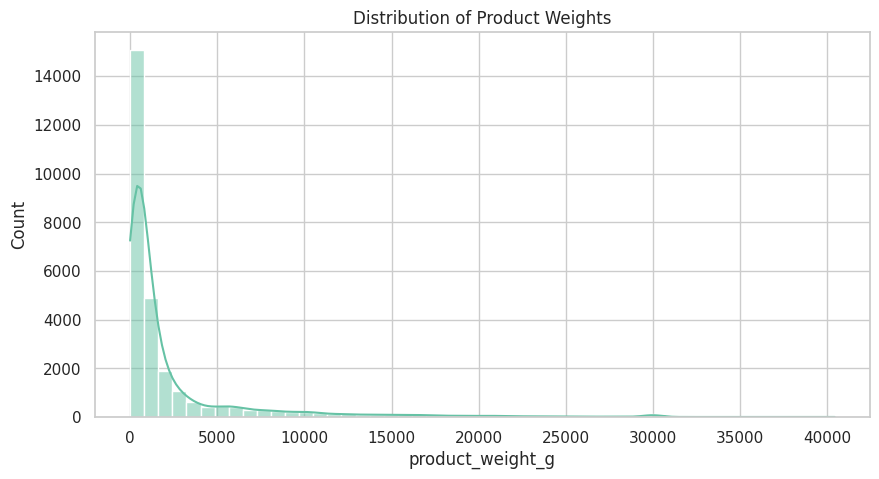

In [ ]:
sns.set(style="whitegrid", palette="Set2")

plt.figure(figsize=(10,5))
sns.histplot(train_products['product_weight_g'], bins=50, kde=True)
plt.title("Distribution of Product Weights")
plt.show()


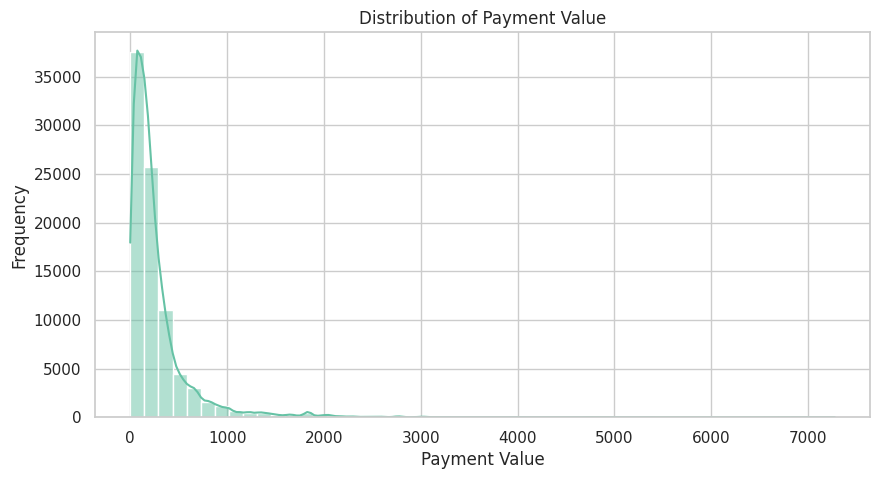

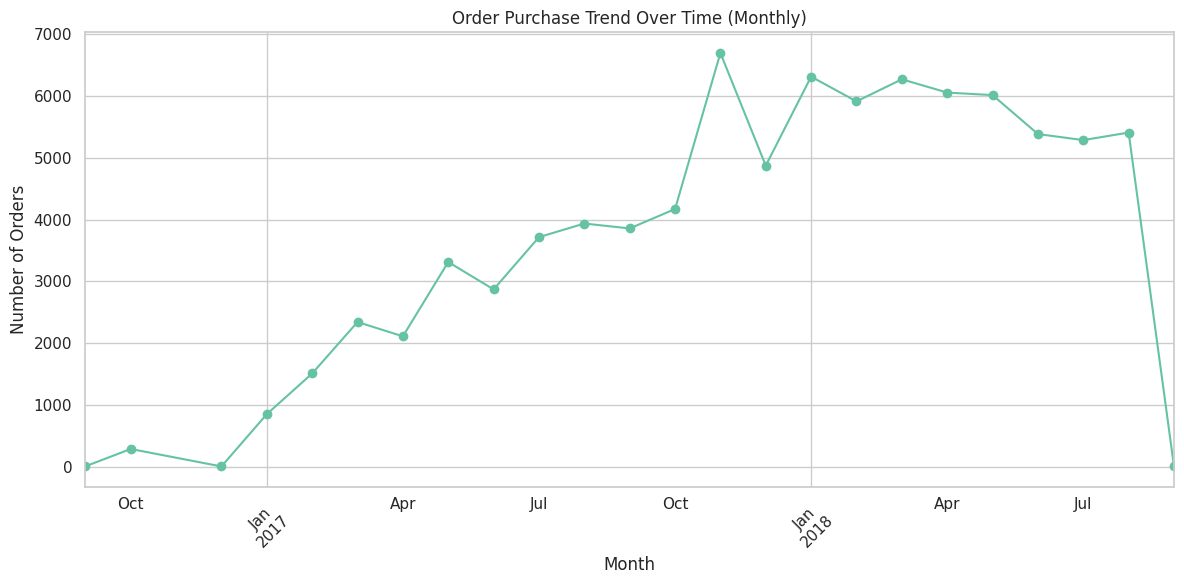

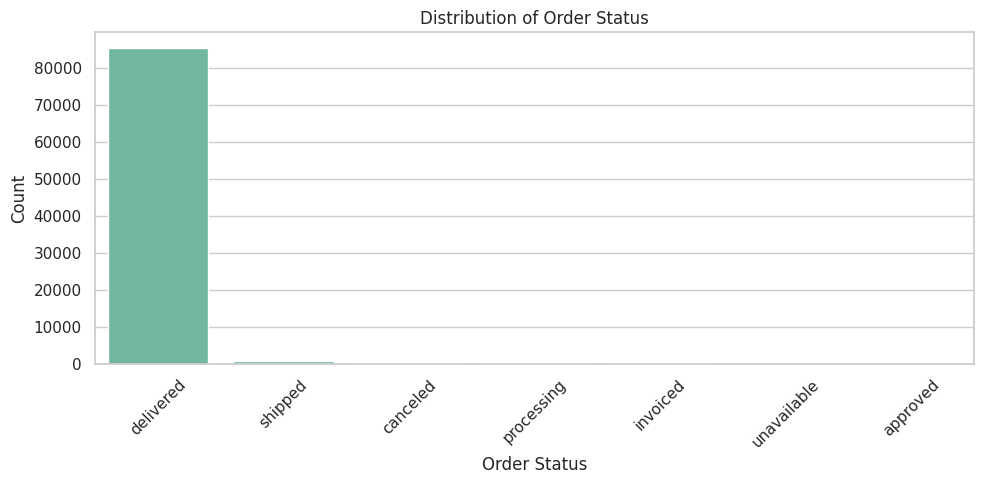

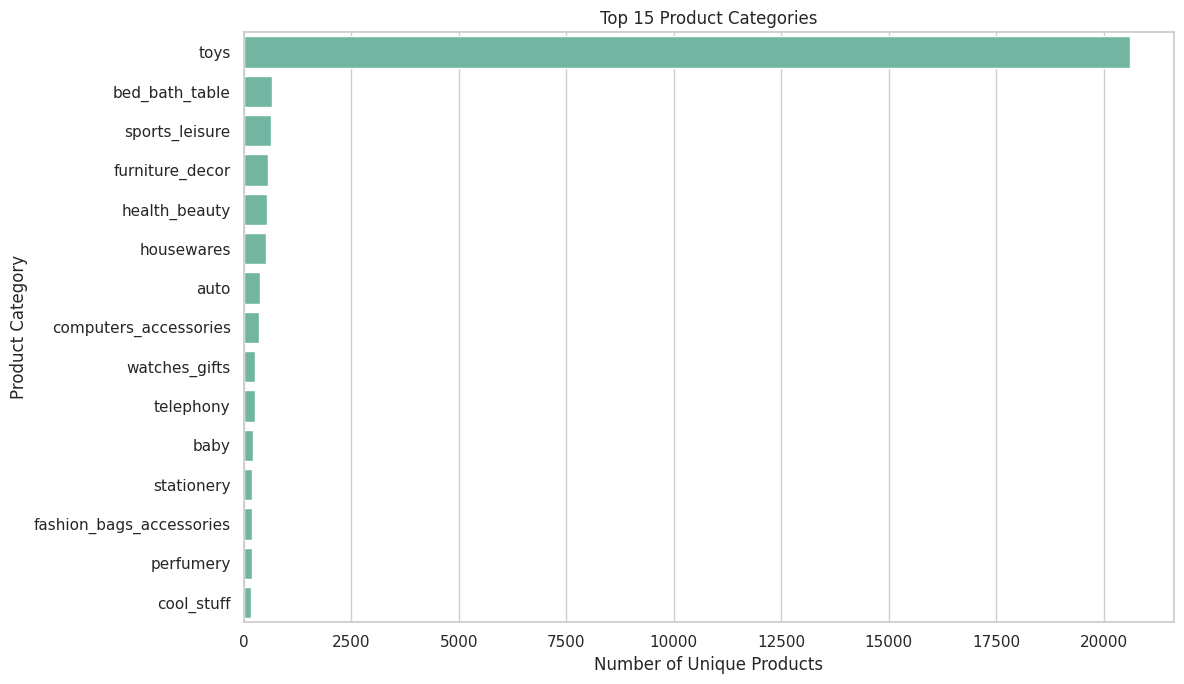

In [ ]:
sns.set(style="whitegrid", palette="Set2")

# 1. Distribution of Payment Value
plt.figure(figsize=(10,5))
sns.histplot(train_payments['payment_value'], bins=50, kde=True)
plt.title("Distribution of Payment Value")
plt.xlabel("Payment Value")
plt.ylabel("Frequency")
plt.show()

# 2. Order Purchase Trend Over Time
# Ensure 'order_purchase_timestamp' is datetime type
train_orders['order_purchase_timestamp'] = pd.to_datetime(train_orders['order_purchase_timestamp'], errors='coerce')
# Filter out any NaT values that resulted from coercion
orders_over_time = train_orders.dropna(subset=['order_purchase_timestamp']).copy()
orders_over_time['purchase_month'] = orders_over_time['order_purchase_timestamp'].dt.to_period('M')
order_counts_monthly = orders_over_time['purchase_month'].value_counts().sort_index()

plt.figure(figsize=(12, 6))
order_counts_monthly.plot(kind='line', marker='o')
plt.title('Order Purchase Trend Over Time (Monthly)')
plt.xlabel('Month')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 3. Distribution of Order Status (Countplot)
plt.figure(figsize=(10,5))
sns.countplot(x='order_status', data=train_orders, order=train_orders['order_status'].value_counts().index)
plt.title("Distribution of Order Status")
plt.xlabel("Order Status")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 4. Top Product Categories (Countplot)
# Ensure products_clean_train is defined and contains the cleaned training product data
# (It was defined in the previous cell, so it should be available)
products_clean_train = train_products.drop_duplicates(subset=['product_id'], keep='first')

plt.figure(figsize=(12, 7))
top_categories = products_clean_train['product_category_name'].value_counts().nlargest(15).index
sns.countplot(y='product_category_name', data=products_clean_train, order=top_categories)
plt.title('Top 15 Product Categories')
plt.xlabel('Number of Unique Products')
plt.ylabel('Product Category')
plt.tight_layout()
plt.show()


Time-Based Analysis

Convert date columns into datetime and explore ordering trends:

## Correlation Matrix

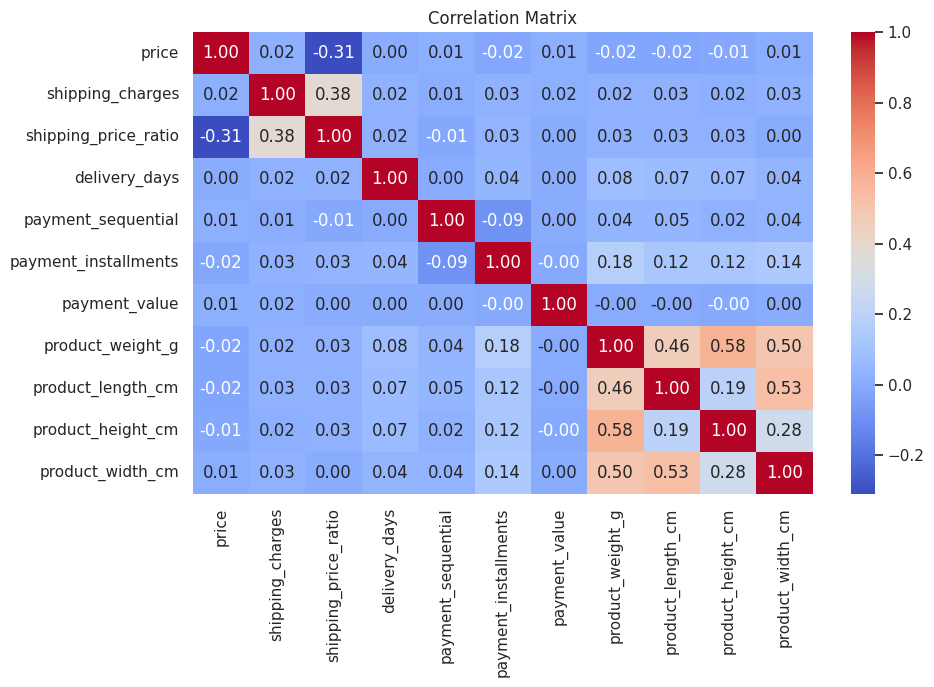

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(m.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()


**Correlation anlaysis**



From our correlation heatmap generated using sns.heatmap(m.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f"), we observe that most features have very weak correlations, indicating low multicollinearity in the dataset. Price shows almost no relationship with delivery days or payments, but it does have a moderate negative correlation with shipping_price_ratio (-0.31), meaning that as product price increases, the relative shipping cost tends to decrease, which is logical for expensive items. Shipping charges are moderately correlated with shipping_price_ratio (0.38), confirming that higher shipping fees directly increase the shipping-to-price proportion. Product physical features show stronger relationships among themselves: for example, product_weight_g and product_height_cm have a correlation of 0.58, while product_width_cm and product_length_cm are correlated at 0.53, proving that physically larger products are generally heavier and dimensionally related. Payment installments have a small but visible relationship with product size, such as 0.18 with product weight, suggesting customers tend to use installments more for heavier (likely more expensive) items. However, delivery_days shows almost zero correlation with most variables (around 0.00–0.08), proving that delivery time is largely independent of product size, price, or payment method in this dataset. Overall, the heatmap proves that product dimensions are inter-related, but most other features remain largely independent, which is good for predictive modeling as it reduces redundancy.

## Merge data for delivery analysis

Combine train_orderitems with products_clean_train using product_id as the key, then merge this result with train_orders on order_id. This will create a unified dataset containing both product information and delivery details. After merging, check the first few rows and the overall shape to confirm the integration was successful.

In [ ]:
# Merge train_orderitems and products_clean_train on 'product_id'
order_product_merged = train_orderitems.merge(products_clean_train, on='product_id', how='inner')

# Merge the result with train_orders on 'order_id'
delivery_analysis_df = order_product_merged.merge(train_orders, on='order_id', how='inner')

# Display the first 5 rows of the final DataFrame
display(delivery_analysis_df.head())

# Print the shape of the final DataFrame
print("\nShape of the delivery_analysis_df:", delivery_analysis_df.shape)

,order_id,product_id,seller_id,price,shipping_charges,shipping_price_ratio,product_category_name,product_weight_g,product_length_cm,product_height_cm,product_width_cm,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_timestamp,order_estimated_delivery_date,delivery_days
0,Axfy13Hk4PIk,90K0C1fIyQUf,ZWM05J9LcBSF,223.51,84.65,0.378730,toys,491.0,19.0,12.0,16.0,hCT0x9JiGXBQ,delivered,2017-10-22 18:57:54,2017-10-22 19:14:13,2017-10-26 22:19:52,2017-11-09,4
1,v6px92oS8cLG,qejhpMGGVcsl,IjlpYfhUbRQs,170.80,23.79,0.139286,watches_gifts,440.0,18.0,14.0,17.0,PxA7fv9spyhx,delivered,2018-06-20 21:40:31,2018-06-20 22:20:20,2018-07-03 22:51:22,2018-07-24,13
2,Ulpf9skrhjfm,qUS5d2pEAyxJ,77p2EYxcM9MD,64.40,17.38,0.269876,costruction_tools_garden,2200.0,16.0,16.0,16.0,g3nXeJkGI0Qw,delivered,2018-02-16 16:19:31,2018-02-17 16:15:35,2018-02-27 01:29:50,2018-03-08,10
3,bwJVWupf2keN,639iGvMyv0De,jWzS0ayv9TGf,264.50,30.72,0.116144,toys,1450.0,68.0,3.0,48.0,EOEsCQ6QlpIg,delivered,2018-08-18 18:04:29,2018-08-18 18:15:16,2018-08-27 20:03:51,2018-09-19,9
4,Dd0QnrMk9Cj5,1lycYGcsic2F,l1pYW6GBnPMr,779.90,30.66,0.039313,toys,300.0,17.0,4.0,12.0,mVz5LO2Vd6cL,delivered,2017-12-22 16:44:04,2017-12-22 17:31:31,2018-01-05 19:22:49,2018-01-18,14



Shape of the delivery_analysis_df: (87192, 18)


**Payment Value Distribution by Category**

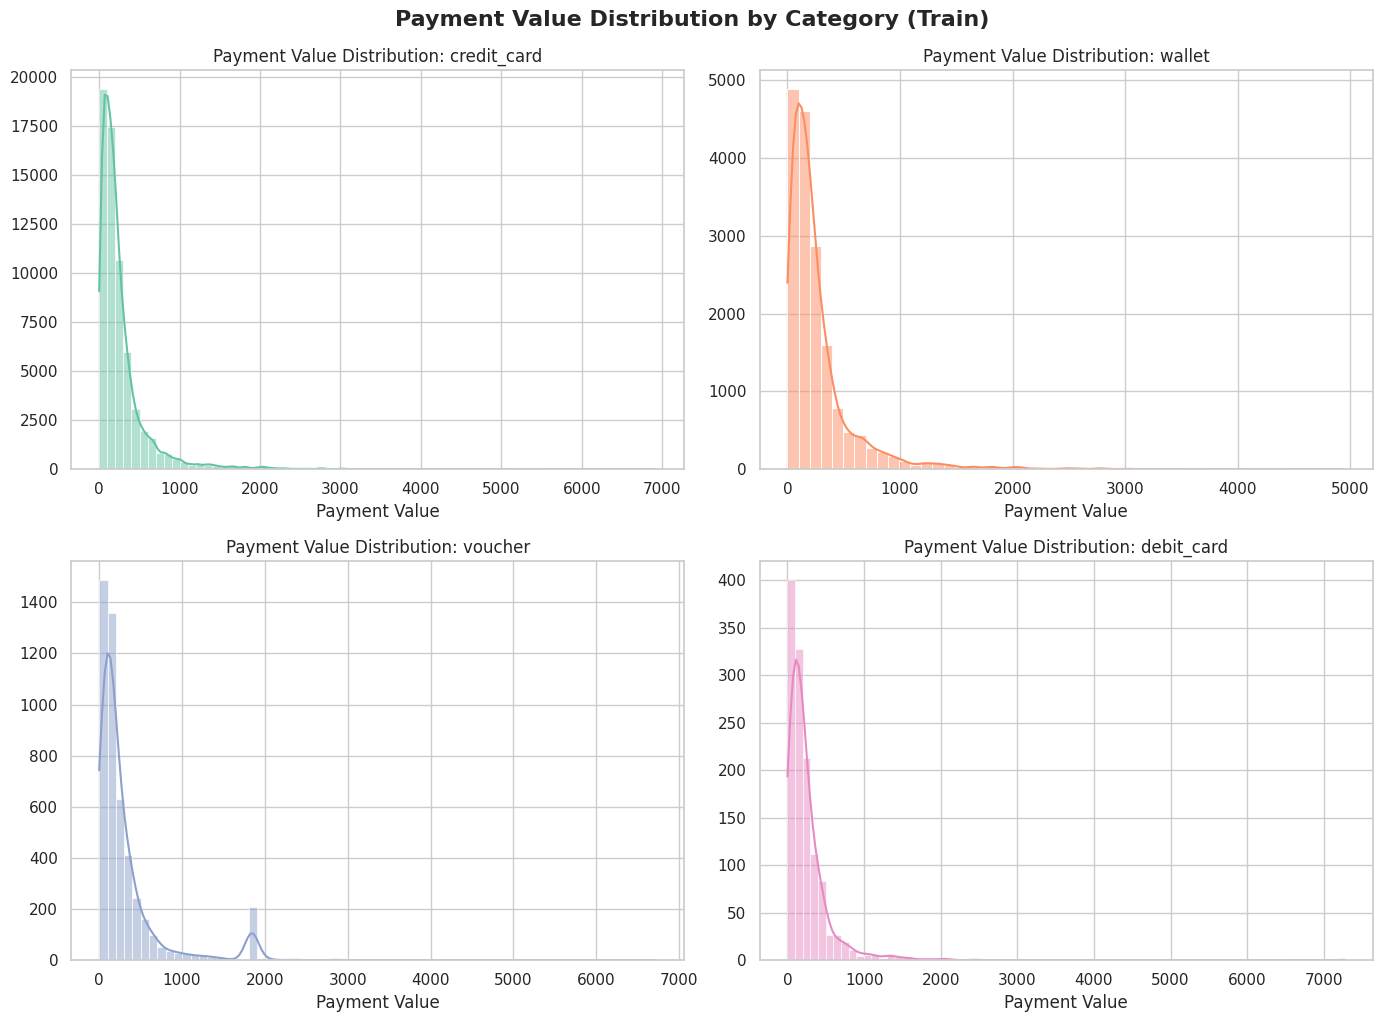

In [ ]:
payment_types = train_payments['payment_type'].unique()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, p_type in enumerate(payment_types):
    sns.histplot(
        data=train_payments[train_payments['payment_type'] == p_type],
        x='payment_value',
        binwidth=100,
        kde=True,
        ax=axes[i],
        color=sns.color_palette('Set2')[i]
    )
    axes[i].set_title(f'Payment Value Distribution: {p_type}')
    axes[i].set_xlabel('Payment Value')
    axes[i].set_ylabel('')

plt.tight_layout()
plt.suptitle('Payment Value Distribution by Category (Train)', fontweight='bold', fontsize=16, y=1.02)
plt.show()


**Insights**

All payment methods show right-skewed distributions, but credit cards handle the widest and highest payment ranges, while wallets and debit cards are mainly used for smaller values, and vouchers are highly concentrated in low payment ranges with occasional high-value usage due to promotions.

credit Has the widest range of payment values, extending above 7000.

Most values are concentrated between 0 – 1000.

Heavy right tail suggests credit cards are used for both small and very expensive purchases.

# This indicates credit cards are the most flexible and dominant method for all price ranges

**Business Insights**

 . **Credit cards** dominate higher transactions, so promotions for high-ticket items

should target credit card users.

 . **Wallet** users are price-sensitive or make frequent small purchases — ideal for small discounts and cashback offers.

 . **Vouchers** are mostly used for low-value or promotional purchases, but the rare high-value peak may suggest premium voucher usage.

 . **Debit cards** are less popular for large transactions, possibly due to limits or user spending behavior

---

# Save final cleaned dataset



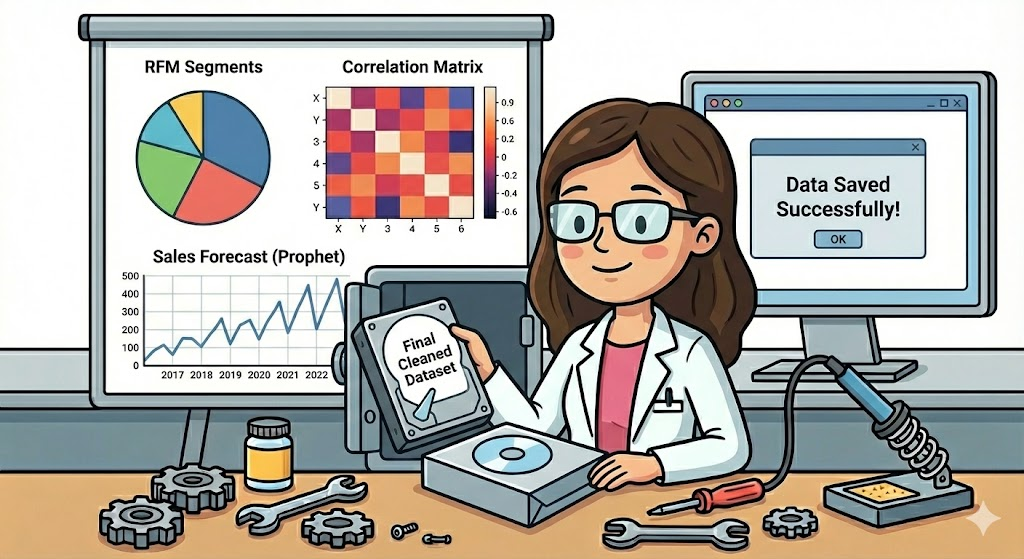

In [ ]:
# Save cleaned train datasets
# TRAIN
train_orders.to_csv("cleaned_train_orders.csv", index=False)
train_orderitems.to_csv("cleaned_train_orderitems.csv", index=False)
train_products.to_csv("cleaned_train_products.csv", index=False)
train_payments.to_csv("cleaned_train_payments.csv", index=False)
train_customers.to_csv("cleaned_train_customers.csv", index=False)

# TEST
test_orders.to_csv("cleaned_test_orders.csv", index=False)
test_orderitems.to_csv("cleaned_test_orderitems.csv", index=False)
test_products.to_csv("cleaned_test_products.csv", index=False)
test_payments.to_csv("cleaned_test_payments.csv", index=False)
test_customers.to_csv("cleaned_test_customers.csv", index=False)

